<a href="https://colab.research.google.com/github/AITrading1995/Trading-/blob/main/startge_analy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [6]:
df = pd.read_excel('/content/ReportTester-52838289.xlsx')
display(df)

,Strategy Tester Report,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,ICMarketsSC-Demo (Build 5660),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Settings,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Expert:,NaN,NaN,new_z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Symbol:,NaN,NaN,CHFSGD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Period:,NaN,NaN,H1 (2025.01.01 - 2026.03.23),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,2026.03.19 14:00:00,210,CHFSGD,buy,in,0.05,1.61263,210,0,0,0,918.3,ZScore_L
486,2026.03.19 16:00:00,211,CHFSGD,sell,out,0.05,1.61608,211,0,0,17.25,935.55,NaN
487,2026.03.19 22:00:00,212,CHFSGD,sell,in,0.05,1.61951,212,0,0,0,935.55,ZScore_S
488,2026.03.20 21:00:00,213,CHFSGD,buy,out,0.05,1.62501,213,0,0,-27.5,908.05,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Strategy Tester Report  453 non-null    object
 1   Unnamed: 1              427 non-null    object
 2   Unnamed: 2              426 non-null    object
 3   Unnamed: 3              454 non-null    object
 4   Unnamed: 4              443 non-null    object
 5   Unnamed: 5              213 non-null    object
 6   Unnamed: 6              426 non-null    object
 7   Unnamed: 7              231 non-null    object
 8   Unnamed: 8              232 non-null    object
 9   Unnamed: 9              428 non-null    object
 10  Unnamed: 10             215 non-null    object
 11  Unnamed: 11             444 non-null    object
 12  Unnamed: 12             214 non-null    object
dtypes: object(13)
memory usage: 49.9+ KB


In [7]:
df_filtered = df.iloc[276:].copy()
display(df_filtered.head())

,Strategy Tester Report,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
276,2025.10.02 00:00:00,1,NaN,balance,NaN,NaN,NaN,NaN,0,0,1000,1000,NaN
277,2025.10.03 18:00:00,2,CHFSGD,sell,in,0.05,1.62083,2,0,0,0,1000,ZScore_S
278,2025.10.06 10:00:00,3,CHFSGD,buy,out,0.05,1.62127,3,0,0,-2.2,997.8,NaN
279,2025.10.06 11:00:00,4,CHFSGD,buy,in,0.05,1.6192,4,0,0,0,997.8,ZScore_L
280,2025.10.06 18:00:00,5,CHFSGD,sell,out,0.05,1.62323,5,0,0,20.15,1017.95,NaN


In [8]:
df_filtered = df_filtered.rename(columns={
    'Strategy Tester Report': 'DateTime',
    'Unnamed: 1': 'Order',
    'Unnamed: 2': 'Symbol',
    'Unnamed: 3': 'Operation',
    'Unnamed: 4': 'Type',
    'Unnamed: 5': 'Lots',
    'Unnamed: 6': 'Price',
    'Unnamed: 7': 'S/L',
    'Unnamed: 8': 'T/P',
    'Unnamed: 9': 'Commission/Swap',
    'Unnamed: 10': 'Profit',
    'Unnamed: 11': 'Balance',
    'Unnamed: 12': 'Custom_Indicator' # Based on 'ZScore_S' in original df tail
})
display(df_filtered.head())

,DateTime,Order,Symbol,Operation,Type,Lots,Price,S/L,T/P,Commission/Swap,Profit,Balance,Custom_Indicator
276,2025.10.02 00:00:00,1,NaN,balance,NaN,NaN,NaN,NaN,0,0,1000,1000,NaN
277,2025.10.03 18:00:00,2,CHFSGD,sell,in,0.05,1.62083,2,0,0,0,1000,ZScore_S
278,2025.10.06 10:00:00,3,CHFSGD,buy,out,0.05,1.62127,3,0,0,-2.2,997.8,NaN
279,2025.10.06 11:00:00,4,CHFSGD,buy,in,0.05,1.6192,4,0,0,0,997.8,ZScore_L
280,2025.10.06 18:00:00,5,CHFSGD,sell,out,0.05,1.62323,5,0,0,20.15,1017.95,NaN


In [9]:
# Convert 'DateTime' to datetime objects
df_filtered['DateTime'] = pd.to_datetime(df_filtered['DateTime'])

In [10]:
# Convert 'Balance' to numeric, coercing errors to NaN
df_filtered['Balance'] = pd.to_numeric(df_filtered['Balance'], errors='coerce')

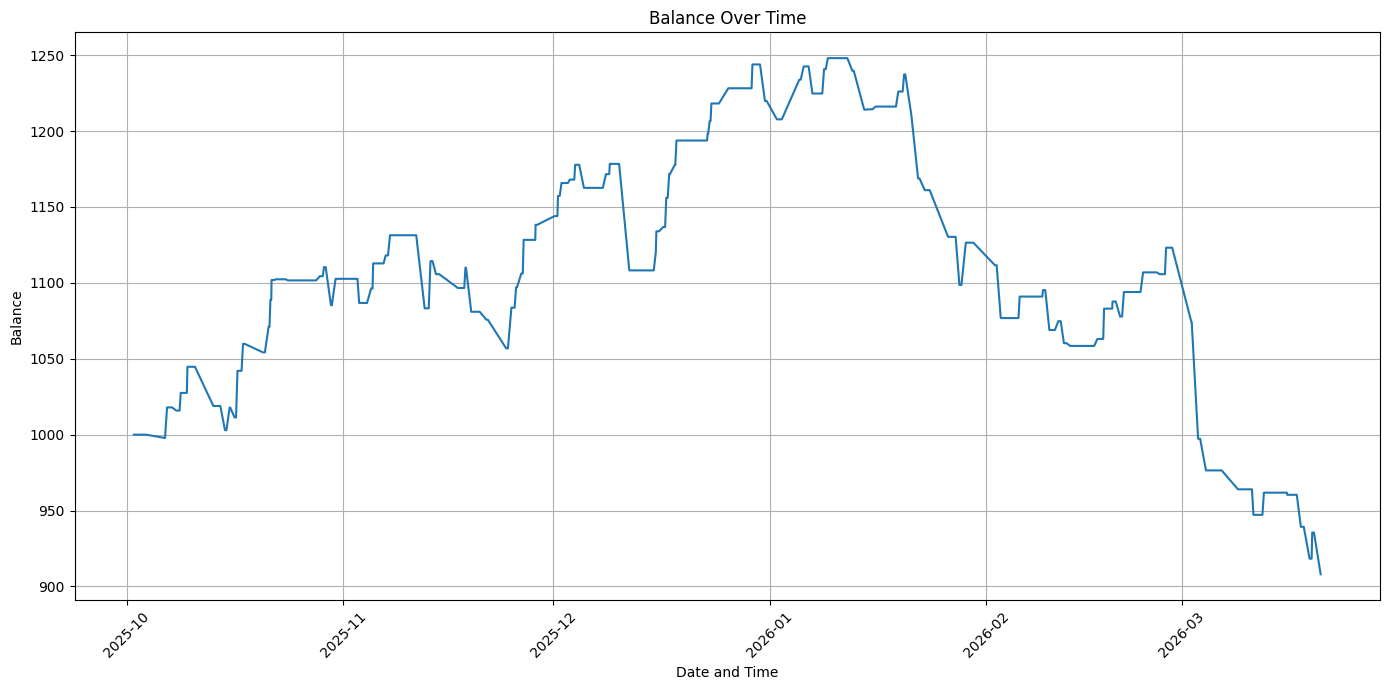

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows where 'Balance' is NaN, as these cannot be plotted
df_plot = df_filtered.dropna(subset=['Balance']).copy()

plt.figure(figsize=(14, 7))
sns.lineplot(x='DateTime', y='Balance', data=df_plot)
plt.title('Balance Over Time')
plt.xlabel('Date and Time')
plt.ylabel('Balance')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
!pip install yfinance

In [12]:
import yfinance as yf

# Get the date range from the df_filtered DateTime column
start_date = df_filtered['DateTime'].min()
end_date = df_filtered['DateTime'].max()

# Define the ticker for CHFSGD (common symbol for CHF/SGD on Yahoo Finance)
ticker = 'CHFSGD=X'

# Download historical data from Yahoo Finance
yf_data = yf.download(ticker, start=start_date, end=end_date)
display(yf_data.head())

/tmp/ipykernel_3521/1887596569.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CHFSGD=X,CHFSGD=X,CHFSGD=X,CHFSGD=X,CHFSGD=X
Date,,,,,
2025-10-02,1.615654,1.618310,1.613514,1.615370,0
2025-10-03,1.616504,1.621121,1.615386,1.616527,0
2025-10-06,1.620028,1.624723,1.618572,1.620082,0
2025-10-07,1.623930,1.624764,1.618460,1.623802,0
2025-10-08,1.619535,1.620020,1.615300,1.619617,0


In [20]:
# Create a temporary DataFrame to process yf_data
yf_data_processed = yf_data.copy()

# Handle 'Date' index and column conflict robustly
if 'Date' in yf_data_processed.columns and yf_data_processed.index.name == 'Date':
    # If 'Date' is already a column AND the index name, keep the column and drop the redundant index
    yf_data_processed = yf_data_processed.reset_index(drop=True)
elif yf_data_processed.index.name == 'Date':
    # If 'Date' is only the index name (not yet a column), reset it to make it a column
    yf_data_processed = yf_data_processed.reset_index()
# else: 'Date' is already a column and index is not named 'Date', or no index name, no action needed for index.

# Flatten any MultiIndex columns into single-level names (if any remain from a complex scenario)
# For a single ticker from yfinance, columns are usually already flattened, but this is a safeguard.
original_cols = yf_data_processed.columns
new_cols = []
for col in original_cols:
    if isinstance(col, tuple):
        new_col_name = '_'.join(filter(None, col))
    else:
        new_col_name = col
    new_cols.append(new_col_name)
yf_data_processed.columns = new_cols

# Normalize the Date column
yf_data_processed['Date'] = yf_data_processed['Date'].dt.normalize()

# Calculate daily returns for Yahoo Finance data
# Based on kernel state, 'Close_CHFSGD=X' is the correct column name.
if 'Close_CHFSGD=X' in yf_data_processed.columns:
    yf_data_processed['Daily_Return'] = yf_data_processed['Close_CHFSGD=X'].pct_change()
elif 'Close' in yf_data_processed.columns:
    yf_data_processed['Daily_Return'] = yf_data_processed['Close'].pct_change()
else:
    print("Warning: 'Close', 'Close_CHFSGD=X' column not found in yf_data_processed.")
    yf_data_processed['Daily_Return'] = None # Assign None or handle as appropriate

yf_data_flat = yf_data_processed # Assign to yf_data_flat for consistency

# Ensure df_filtered is sorted by DateTime for correct balance calculation
df_filtered_sorted = df_filtered.sort_values(by='DateTime').copy()

# Calculate daily returns for the Balance column
df_filtered_sorted['Balance_Daily_Return'] = df_filtered_sorted['Balance'].pct_change()

# Align both dataframes on date for comparison
# We'll use the date part of DateTime for merging
df_filtered_sorted['Date'] = df_filtered_sorted['DateTime'].dt.normalize()

merged_df = pd.merge(
    df_filtered_sorted[['Date', 'Balance_Daily_Return']],
    yf_data_flat[['Date', 'Daily_Return']], # Use the processed DataFrame
    on='Date',
    how='inner'
)

display(merged_df.head())

,Date,Balance_Daily_Return,Daily_Return
0,2025-10-02,NaN,NaN
1,2025-10-03,0.000000,0.000526
2,2025-10-06,-0.002200,0.002180
3,2025-10-06,0.000000,0.002180
4,2025-10-06,0.020194,0.002180


In [19]:
print(yf_data.head())

            Close_CHFSGD=X  High_CHFSGD=X  Low_CHFSGD=X  Open_CHFSGD=X  \
Date                                                                     
2025-10-02        1.615654       1.618310      1.613514       1.615370   
2025-10-03        1.616504       1.621121      1.615386       1.616527   
2025-10-06        1.620028       1.624723      1.618572       1.620082   
2025-10-07        1.623930       1.624764      1.618460       1.623802   
2025-10-08        1.619535       1.620020      1.615300       1.619617   

            Volume_CHFSGD=X Daily_Return       Date  
Date                                                 
2025-10-02                0         None 2025-10-02  
2025-10-03                0         None 2025-10-03  
2025-10-06                0         None 2025-10-06  
2025-10-07                0         None 2025-10-07  
2025-10-08                0         None 2025-10-08  


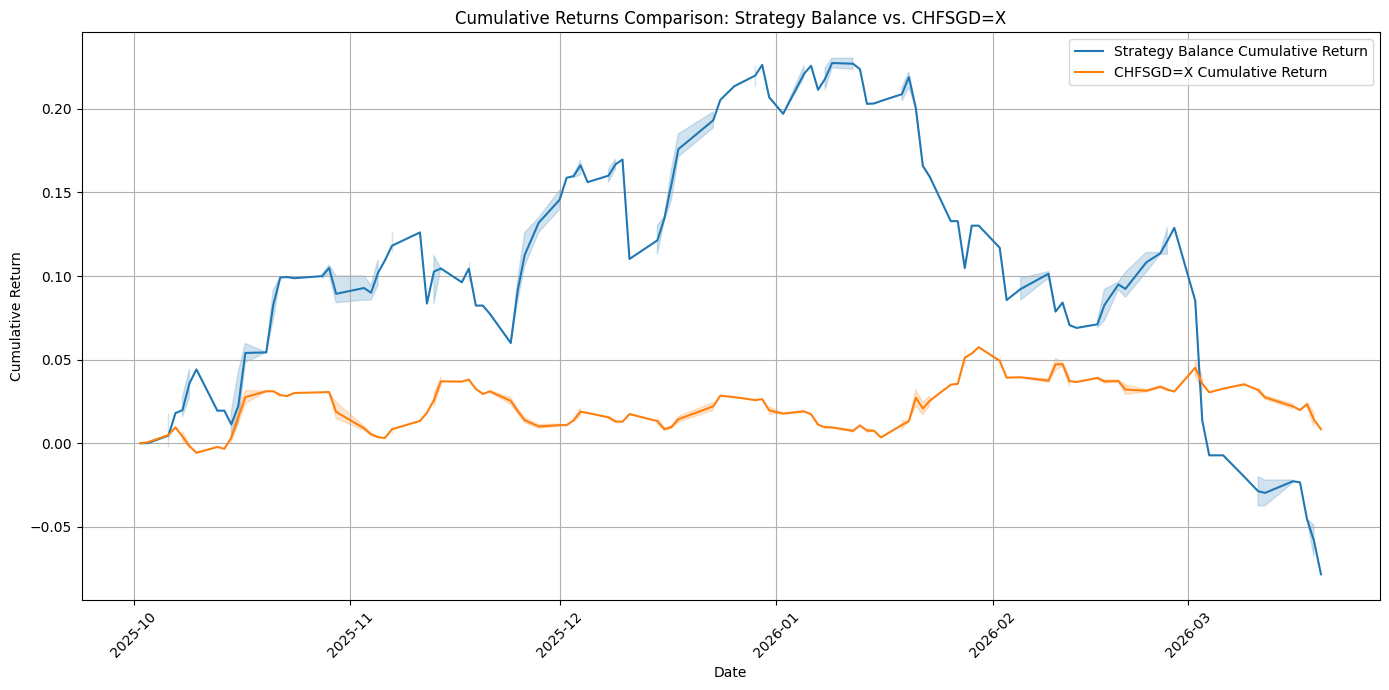

In [22]:
merged_df['Balance_Cumulative_Return'] = merged_df['Balance_Daily_Return'].fillna(0).cumsum()
merged_df['Ticker_Cumulative_Return'] = merged_df['Daily_Return'].fillna(0).cumsum()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Balance_Cumulative_Return', data=merged_df, label='Strategy Balance Cumulative Return')
sns.lineplot(x='Date', y='Ticker_Cumulative_Return', data=merged_df, label=f'{ticker} Cumulative Return')

plt.title('Cumulative Returns Comparison: Strategy Balance vs. CHFSGD=X')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sharpe Ratio Calculation
To compare the risk-adjusted returns of the strategy versus the market, we can calculate the Sharpe Ratio. The Sharpe Ratio measures the performance of an investment compared to a risk-free asset, after adjusting for its risk.

For simplicity, we'll assume a risk-free rate of 0 for this calculation.

$Sharpe Ratio = \frac{E[R_p - R_f]}{\sigma_p} \approx \frac{Mean(Daily Return)}{StdDev(Daily Return)}$

In [23]:
# Calculate daily returns for strategy and ticker (already available in merged_df)

# Drop NaN values from daily returns before calculation
strategy_daily_returns = merged_df['Balance_Daily_Return'].dropna()
ticker_daily_returns = merged_df['Daily_Return'].dropna()

# Calculate mean daily return
mean_strategy_return = strategy_daily_returns.mean()
mean_ticker_return = ticker_daily_returns.mean()

# Calculate standard deviation of daily return (risk)
std_strategy_return = strategy_daily_returns.std()
std_ticker_return = ticker_daily_returns.std()

# Calculate Sharpe Ratio (assuming risk-free rate = 0)
# Annualize for better comparison (assuming 252 trading days in a year)
annualization_factor = 252

sharpe_strategy = (mean_strategy_return / std_strategy_return) * (annualization_factor**0.5) if std_strategy_return != 0 else float('nan')
sharpe_ticker = (mean_ticker_return / std_ticker_return) * (annualization_factor**0.5) if std_ticker_return != 0 else float('nan')

print(f"Strategy Sharpe Ratio: {sharpe_strategy:.4f}")
print(f"Ticker ({ticker}) Sharpe Ratio: {sharpe_ticker:.4f}")

if sharpe_strategy > sharpe_ticker:
    print("\nThe strategy has a higher risk-adjusted return than the ticker.")
elif sharpe_strategy < sharpe_ticker:
    print("\nThe ticker has a higher risk-adjusted return than the strategy.")
else:
    print("\nThe strategy and the ticker have similar risk-adjusted returns.")

Strategy Sharpe Ratio: -0.4530
Ticker (CHFSGD=X) Sharpe Ratio: 0.1861

The ticker has a higher risk-adjusted return than the strategy.


### Correlation Analysis
Let's visualize the correlation between the daily returns of the strategy and the market (`CHFSGD=X`). A scatter plot can help us understand if the strategy's movements are aligned with or diverge from the market movements.

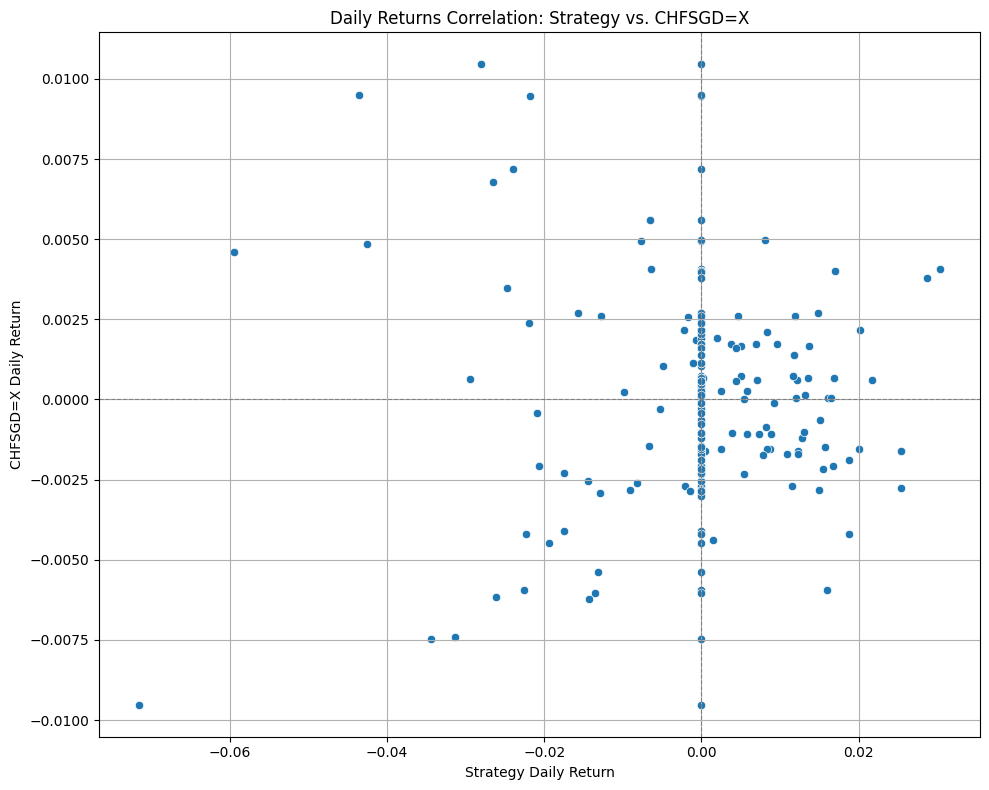


Correlation between Strategy Daily Return and CHFSGD=X Daily Return: 0.0034


In [24]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Balance_Daily_Return', y='Daily_Return', data=merged_df)
plt.title('Daily Returns Correlation: Strategy vs. CHFSGD=X')
plt.xlabel('Strategy Daily Return')
plt.ylabel('CHFSGD=X Daily Return')
plt.grid(True)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add vertical line at x=0
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add horizontal line at y=0
plt.tight_layout()
plt.show()

# Also print the numerical correlation coefficient
correlation = merged_df['Balance_Daily_Return'].corr(merged_df['Daily_Return'])
print(f"\nCorrelation between Strategy Daily Return and CHFSGD=X Daily Return: {correlation:.4f}")

### Maximum Drawdown (MDD) Calculation
The Maximum Drawdown (MDD) is a measure of the largest percentage drop from a peak to a trough in the cumulative returns of an investment over a specified period. It is an indicator of downside risk.

Maximum Drawdown of the Strategy: inf


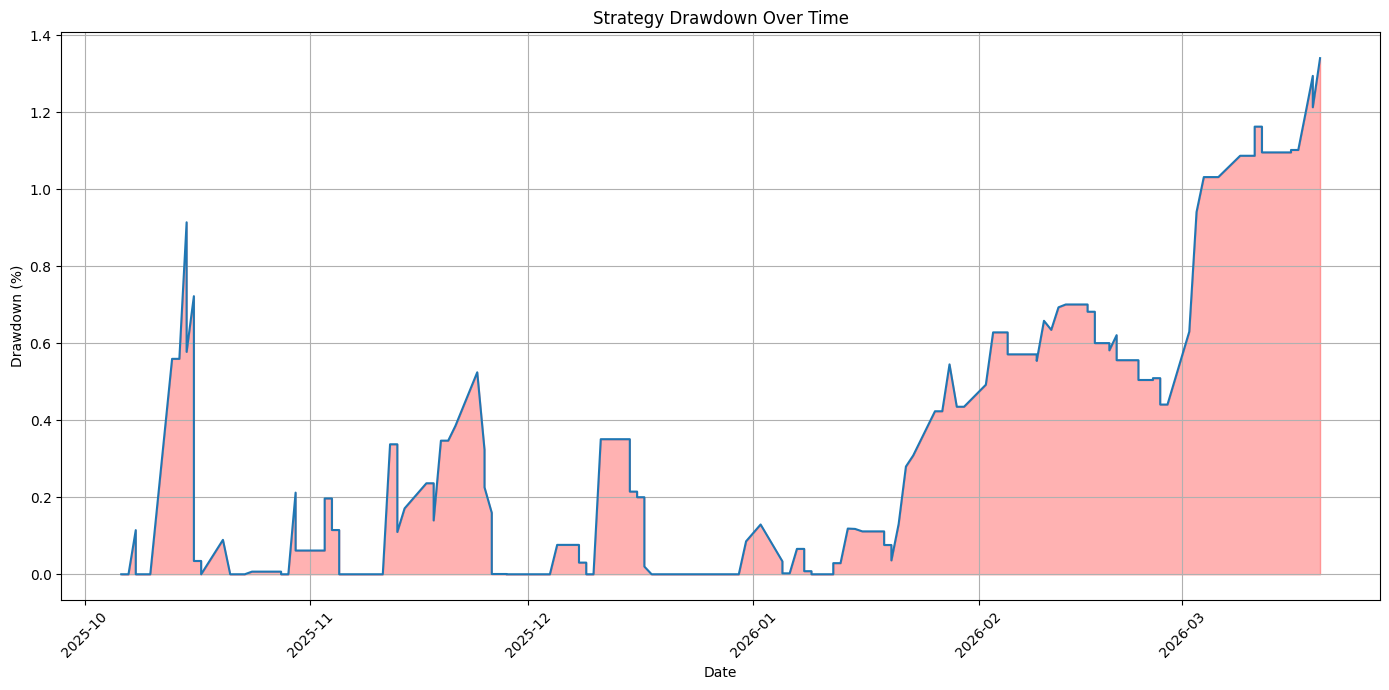

In [28]:
# Calculate the cumulative maximum return for the strategy
strategy_cumulative_max = merged_df['Balance_Cumulative_Return'].cummax()

# Calculate the drawdown
strategy_drawdown = strategy_cumulative_max - merged_df['Balance_Cumulative_Return']

# Calculate the percentage drawdown
strategy_percentage_drawdown = strategy_drawdown / strategy_cumulative_max

# Find the maximum drawdown (as a percentage)
max_drawdown = strategy_percentage_drawdown.max()

print(f"Maximum Drawdown of the Strategy: {max_drawdown:.4f}")

# Visualize the drawdown over time (optional, but good for understanding)
plt.figure(figsize=(14, 7))
plt.plot(merged_df['Date'], strategy_percentage_drawdown, label='Strategy Drawdown')
plt.fill_between(merged_df['Date'], strategy_percentage_drawdown, color='red', alpha=0.3)
plt.title('Strategy Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Equity Curve Comparison

Let's visualize the equity curve for both the strategy and the market (CHFSGD=X). The equity curve starts at 1, representing an initial investment, and shows how that investment would have grown over time based on the cumulative returns.

### Monthly Sharpe Ratio Calculation

Let's calculate the Sharpe Ratio on a monthly basis to observe performance trends over different periods. We will resample the daily returns to monthly returns.

In [33]:
# Set 'Date' as index for resampling
merged_df_indexed = merged_df.set_index('Date')

# Resample daily returns to monthly returns
monthly_strategy_returns = merged_df_indexed['Balance_Daily_Return'].resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_ticker_returns = merged_df_indexed['Daily_Return'].resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Drop NaN values (months with no valid returns)
monthly_strategy_returns = monthly_strategy_returns.dropna()
monthly_ticker_returns = monthly_ticker_returns.dropna()

# Calculate mean monthly return
mean_monthly_strategy_return = monthly_strategy_returns.mean()
mean_monthly_ticker_return = monthly_ticker_returns.mean()

# Calculate standard deviation of monthly return (risk)
std_monthly_strategy_return = monthly_strategy_returns.std()
std_monthly_ticker_return = monthly_ticker_returns.std()

# Annualization factor for monthly Sharpe Ratio (assuming 12 months in a year)
monthly_annualization_factor = 12

# Calculate Monthly Sharpe Ratio (assuming risk-free rate = 0)
sharpe_strategy_monthly = (mean_monthly_strategy_return / std_monthly_strategy_return) * (monthly_annualization_factor**0.5) if std_monthly_strategy_return != 0 else float('nan')
sharpe_ticker_monthly = (mean_monthly_ticker_return / std_monthly_ticker_return) * (monthly_annualization_factor**0.5) if std_monthly_ticker_return != 0 else float('nan')

print(f"Strategy Monthly Sharpe Ratio: {sharpe_strategy_monthly:.4f}")
print(f"Ticker ({ticker}) Monthly Sharpe Ratio: {sharpe_ticker_monthly:.4f}")

if sharpe_strategy_monthly > sharpe_ticker_monthly:
    print("\nThe strategy has a higher monthly risk-adjusted return than the ticker.")
elif sharpe_strategy_monthly < sharpe_ticker_monthly:
    print("\nThe ticker has a higher monthly risk-adjusted return than the strategy.")
else:
    print("\nThe strategy and the ticker have similar monthly risk-adjusted returns.")

Strategy Monthly Sharpe Ratio: -0.3436
Ticker (CHFSGD=X) Monthly Sharpe Ratio: 0.2024

The ticker has a higher monthly risk-adjusted return than the strategy.


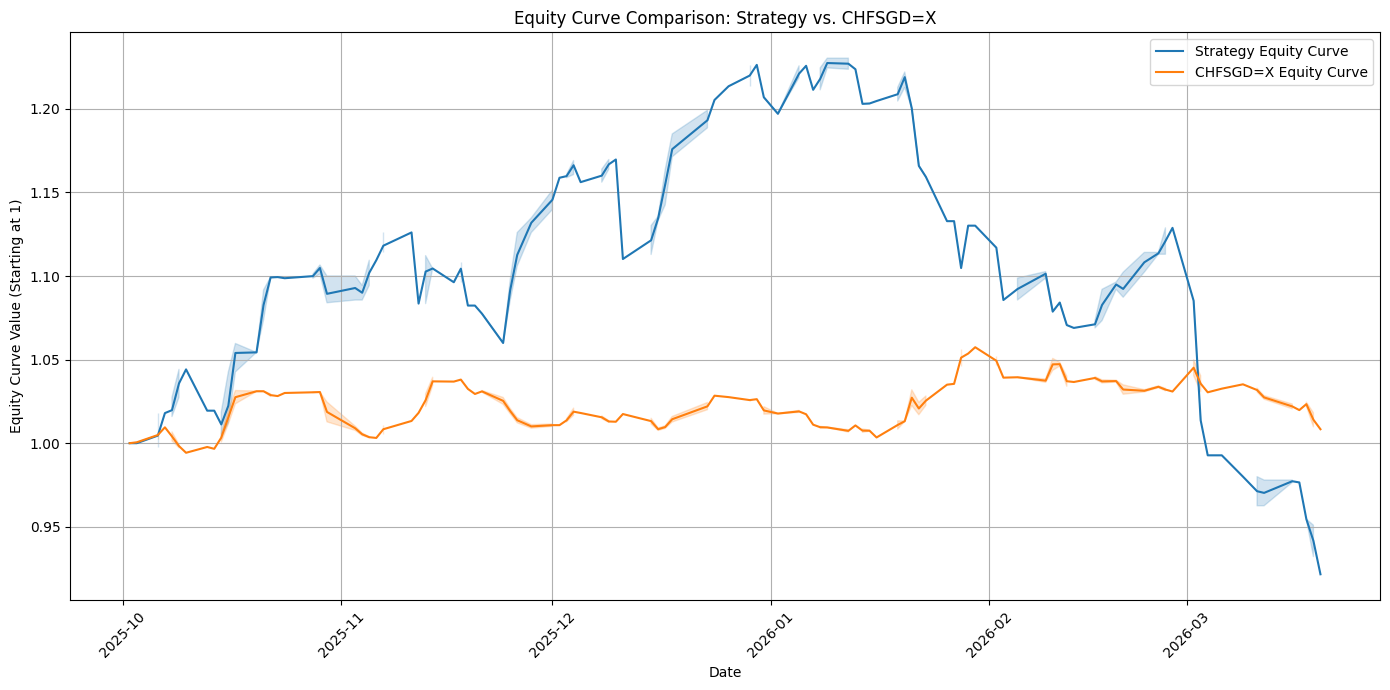

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the equity curve (1 + cumulative returns) for both
merged_df['Strategy_Equity_Curve'] = 1 + merged_df['Balance_Cumulative_Return']
merged_df['Ticker_Equity_Curve'] = 1 + merged_df['Ticker_Cumulative_Return']

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Strategy_Equity_Curve', data=merged_df, label='Strategy Equity Curve')
sns.lineplot(x='Date', y='Ticker_Equity_Curve', data=merged_df, label=f'{ticker} Equity Curve')

plt.title('Equity Curve Comparison: Strategy vs. CHFSGD=X')
plt.xlabel('Date')
plt.ylabel('Equity Curve Value (Starting at 1)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Daily Returns Statistics
Let's look at the basic statistical summary of both the strategy's daily returns and the market's daily returns. This helps in understanding their distribution, central tendency, and volatility (standard deviation).

In [30]:
print("\n--- Strategy Daily Returns Statistics ---")
display(strategy_daily_returns.describe())

print("\n--- Ticker (CHFSGD=X) Daily Returns Statistics ---")
display(ticker_daily_returns.describe())


--- Strategy Daily Returns Statistics ---


,Balance_Daily_Return
count,212.000000
mean,-0.000370
std,0.012963
min,-0.071545
25%,0.000000
50%,0.000000
75%,0.004439
max,0.030355



--- Ticker (CHFSGD=X) Daily Returns Statistics ---


,Daily_Return
count,212.000000
mean,0.000039
std,0.003358
min,-0.009522
25%,-0.001700
50%,0.000049
75%,0.001757
max,0.010453
